In [ ]:
#HW7.1. Heat Pump
#at steady state


import numpy as np

m_dot = 4.90 # kg/min
p1 = 1.80 # bars
T1 = -10.00 # C
p2 = 8.00 # bars
h2 = 270.00 # kJ/kg
W = 2.50 # kW
p3 = 8.00 # bars
T3 = 28.00 # C
T4 = -12.00 # C

h1=242.06 #过热蒸汽
h3 =88.62   #28C 8bars
# h3=(28-26.72)/(31.33-26.72)*(93.42-86.78)+86.78  
h4=h3

#(a) from the refrigerant to the return air passing through the condenser.
Qa=m_dot*(h2-h3) # kJ/min
#(b) between the compressor and the surroundings.
Qb=-W*60-m_dot*(h1-h2) # kJ/min
#(c) from the outside air to the refrigerant passing through the evaporator.
Qc=m_dot*(h1-h4) # kJ/min   
print(Qa)
print(Qb)
print(Qc)
#放出热能Q为正
#膨胀阀被视为绝热节流过程


888.7620000000001
-13.093999999999994
751.856


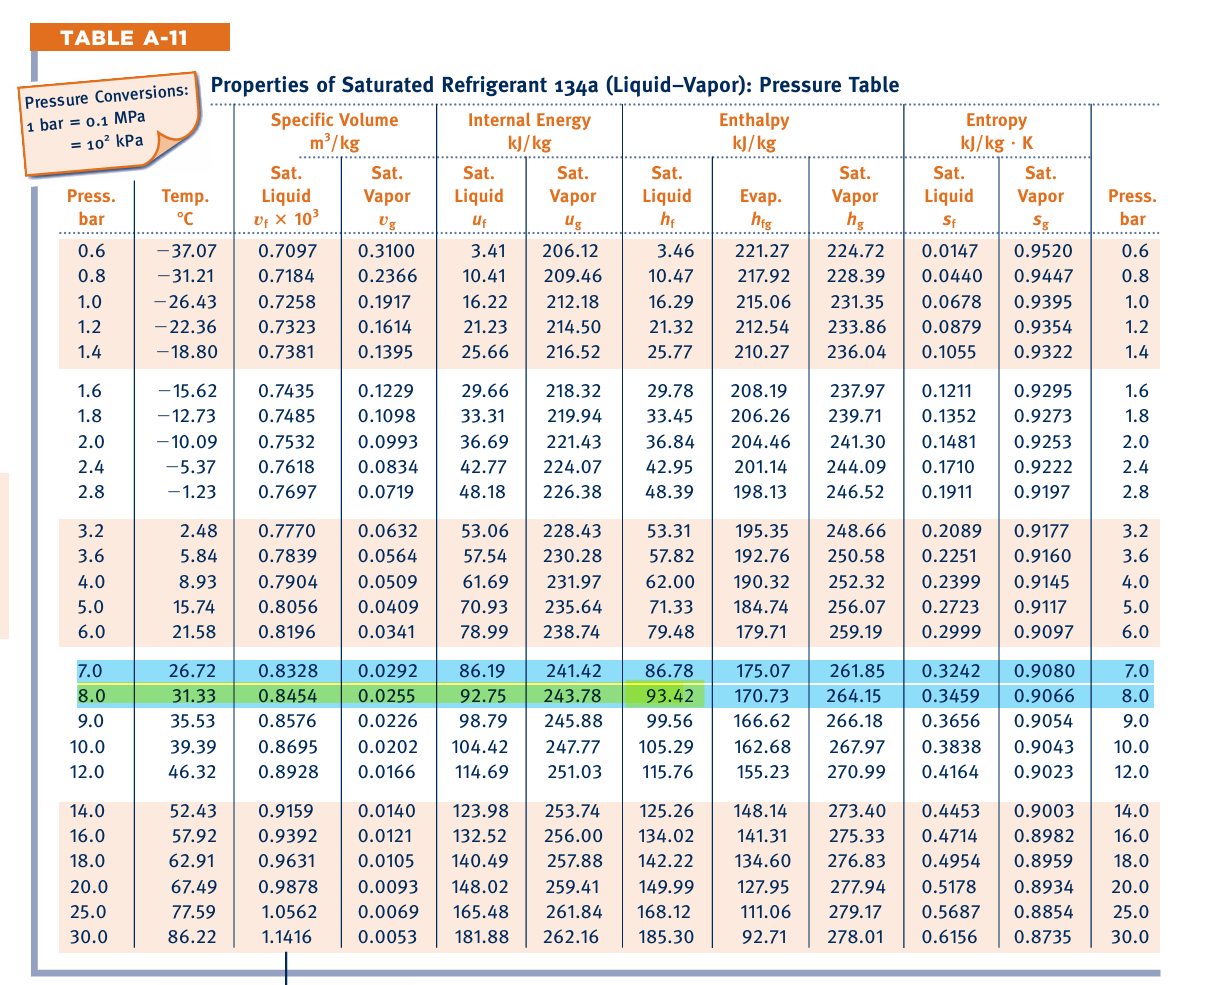

In [5]:
#HW7.2. heat pump2
import numpy as np
from sympy import *
beta = 5.0 # Coefficient of Performance
T_H_C = 23.0 # °C
Q_dot_H = 4.8 # kW

COP=beta
T_H_C=T_H_C+273.15 # K
power_input=Q_dot_H/(COP+1) # kW
print(power_input)

#beta=Tc/(Th-Tc)
Th=T_H_C
Tc=S('Tc')
beta-Tc/(Th-Tc)
x=solve(beta-Tc/(Th-Tc))[0]
print(x)

0.7999999999999999
246.791666666667


根据能量守恒定律（热力学第一定律），排出的总热量等于从内部吸收的热量加上压缩机输入的功

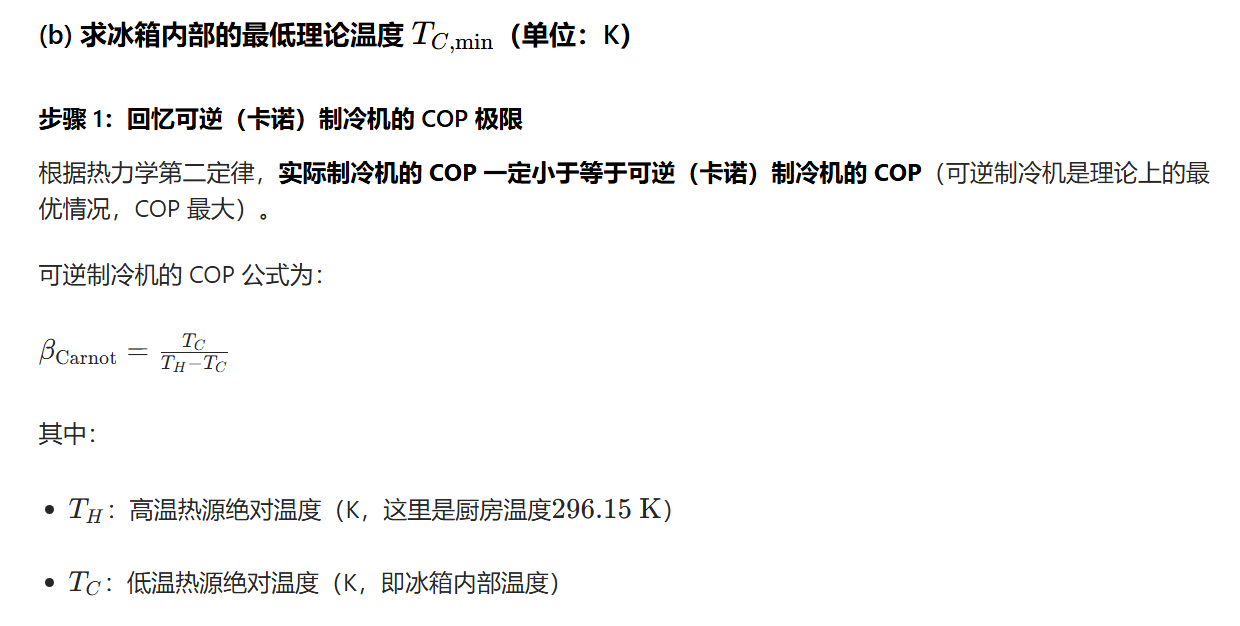

In [ ]:
#HW7.3. Power Cycle



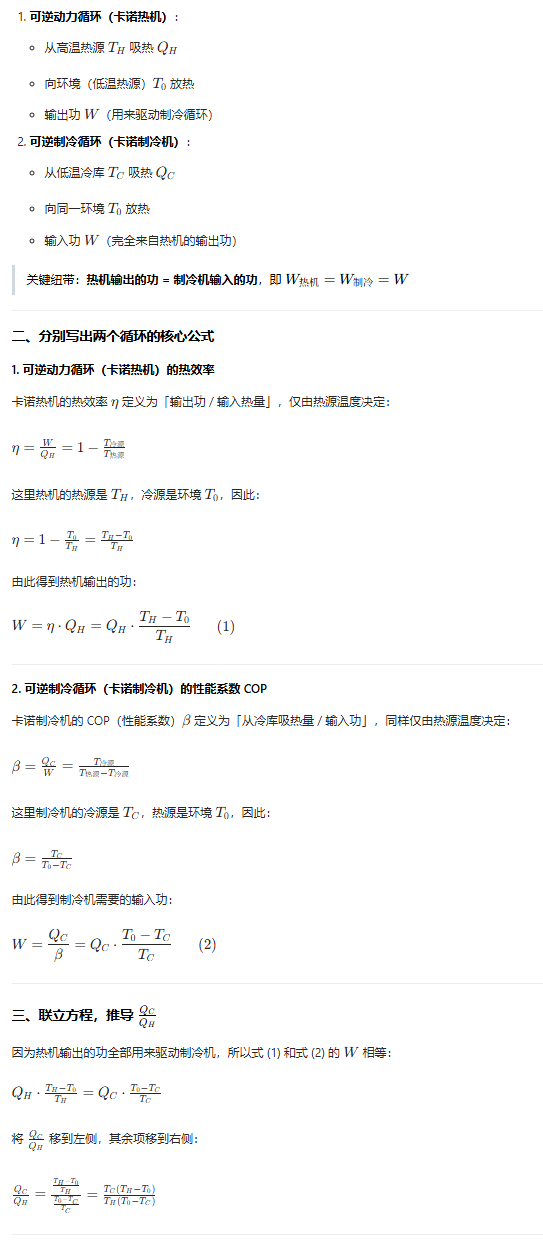

In [2]:
#HW7.4. carnot_simple1
import numpy as np

T_C = 300.00 # K
P_1 = 120.00 # kPa
P_4 = 90.00 # kPa
eta_max = 0.60 # %

# 已知参数
T_C = 300.0       # 低温等温过程温度，K
P_low = P_4      # 压缩初始压力，kPa
P_high = P_1      # 压缩终了压力，kPa
eta = eta_max         # 卡诺循环热效率
R = 8.314         # 通用气体常数，kJ/(kmol·K)

# (a) 计算等温膨胀的高温温度T_H
T_H = T_C / (1 - eta)

# (b) 计算每kmol气体的净功
Q_C = R * T_C * np.log(P_high / P_low)  # 低温过程放热量
Q_H = Q_C * T_H / T_C                    # 高温过程吸热量
W_net = eta * Q_H                        # 循环净功

# 输出结果
print(f"(a) 等温膨胀温度 T_H = {T_H} K")
print(f"(b) 单位kmol净功 W_net = {W_net:.2f} kJ/kmol")

(a) 等温膨胀温度 T_H = 750.0 K
(b) 单位kmol净功 W_net = 1076.30 kJ/kmol


In [4]:
#HW7.5. carnot_vapor1
import numpy as np

P_high = 50.00 # bar
P_low = 5.00 # bar
W_23_given = 364.31 # kJ/kg


W23 = W_23_given   # 绝热膨胀过程做功，kJ/kg

# ---------- 水蒸气表准确参数（IAPWS-97） ----------
# 50bar(5MPa)饱和参数
T_H = 263.941 + 273.15  # 饱和温度，K
h_f1 = 1154.23    # 饱和液焓，kJ/kg
h_g1 = 2794.33    # 饱和汽焓，kJ/kg
u_f1 = 1147.78    # 饱和液内能，kJ/kg
u_g1 = 2597.04    # 饱和汽内能，kJ/kg
s_f1 = 2.9202     # 饱和液熵，kJ/(kg·K)
s_g1 = 5.9737     # 饱和汽熵，kJ/(kg·K)
v_f1 = 0.0012859  # 饱和液比体积，m³/kg
v_g1 = 0.039448   # 饱和汽比体积，m³/kg

# 5bar(0.5MPa)饱和参数
T_C = 151.831 + 273.15  # 饱和温度，K
u_f3 = 639.54     # 饱和液内能，kJ/kg
u_g3 = 2560.7     # 饱和汽内能，kJ/kg
s_f3 = 1.8604     # 饱和液熵，kJ/(kg·K)
s_g3 = 6.8207     # 饱和汽熵，kJ/(kg·K)
u_fg3 = u_g3 - u_f3  # 汽化内能差，kJ/kg
s_fg3 = s_g3 - s_f3  # 汽化熵差，kJ/(kg·K)

# ---------- (a) 各过程的热量和功计算 ----------
# 过程1→2：等温膨胀
Q12_m = h_g1 - h_f1  # 单位质量吸热量
W12_m = P_high * 1e5 * (v_g1 - v_f1) / 1000  # 单位质量做功，转换单位Pa·m³=J→kJ

# 过程2→3：绝热膨胀（Q=0，题目已给W23，计算状态3内能）
u2 = u_g1
u3 = u2 - W23

# 过程3→4：等温压缩
delta_s_34 = s_f1 - s_g1  # 熵变s4-s3，s4=s1=s_f1，s3=s2=s_g1
Q34_m = T_C * delta_s_34  # 单位质量热量
# 计算状态4干度和内能
x4 = (s_f1 - s_f3) / s_fg3
u4 = u_f3 + x4 * u_fg3
delta_u_34 = u4 - u3
W34_m = Q34_m - delta_u_34  # 单位质量做功

# 过程4→1：绝热压缩（Q=0）
W41_m = u4 - u_f1  # 单位质量做功

# ---------- (b) 热效率计算 ----------
W_net = W12_m + W23 + W34_m + W41_m
eta = W_net / Q12_m * 100  # 转换为百分比

# ---------- 输出结果 ----------
print("(a) 各过程单位质量热量与功：")
print(f"Q12/m = {Q12_m:.2f} kJ/kg")
print(f"W12/m = {W12_m:.2f} kJ/kg")
print(f"Q34/m = {Q34_m:.2f} kJ/kg")
print(f"W34/m = {W34_m:.2f} kJ/kg")
print(f"W41/m = {W41_m:.2f} kJ/kg")
print("\n(b) 热效率：")
print(f"η = {eta:.2f} %")

(a) 各过程单位质量热量与功：
Q12/m = 1640.10 kJ/kg
W12/m = 190.81 kJ/kg
Q34/m = -1297.68 kJ/kg
W34/m = -114.96 kJ/kg
W41/m = -97.77 kJ/kg

(b) 热效率：
η = 20.88 %
